# Imports

In [1]:
import sys

repo_path = '/Users/zohairshafi/Local Workspace/spectral_nature/'
sys.path.append(repo_path)
from src.utils.alpaca_utils import *


with open(os.path.join(cache_path, 'headers.pkl'), 'rb') as file: 
    headers, paper_header = pkl.load(file)

# Data Collection

In [ ]:
# Import the worker function from a top-level module so it's picklable by child processes
from src.utils.run_symbol_worker import run_symbol

symbol_list = ['GLD']

# Progress logging setup
repo_path = '/Users/zohairshafi/Local Workspace/spectral_nature/'
progress_log_path = os.path.join(repo_path, 'cache', 'progress.log')
# Initialize/clear previous log
with open(progress_log_path, 'w') as _f:
    _f.write(f'Progress log started {datetime.utcnow().isoformat()}Z\n')

def log_progress(message: str):
    timestamp = datetime.utcnow().isoformat()
    with open(progress_log_path, 'a') as f:
        f.write(f'[{timestamp}] {message}\n')

# Ensure spawn start method (safer on macOS / notebooks)
try:
    mp.set_start_method('spawn', force=False)
except RuntimeError:
    # Already set in this interpreter
    pass

# Multiprocessing execution block
summaries = []

max_workers = min(8, cpu_count(), len(symbol_list))  # adjust as desired
log_progress(f'Launching process pool max_workers={max_workers} total_symbols={len(symbol_list)}')

with Pool(processes=max_workers) as pool:
    # Bind constant args for each worker using partial (picklable since function is module-level)
    worker_fn = partial(run_symbol, repo_path=repo_path, progress_log_path=progress_log_path)
    total = len(symbol_list)
    for completed, summary in enumerate(pool.imap_unordered(worker_fn, symbol_list), 1):
        summaries.append(summary)
        sym = summary.get('symbol', 'UNKNOWN')
        log_progress(f'COMPLETED symbol={sym} ({completed}/{total})')
        if completed % 2 == 0 or completed == total:
            pct = (completed/total)*100
            log_progress(f'OVERALL progress={completed}/{total} ({pct:0.1f}%)')

summary_df = pd.DataFrame(summaries)

display(summary_df)
print(f'Progress log written to: {progress_log_path}')

KeyboardInterrupt: 

# Data Pre-Processing

In [2]:
symbol_list = ['AAPL', 'MSFT', 'QCOM', 'GOOGL', 'AMZN', 'TSLA', 'PINS', 'NFLX', 'NVDA', 'META', 'SPY', 'QQQ'] + ['RIVN', 'CRWV', 'SMR', 'CEG', 'CAT'] + ['GLD']

data = []
for symbol in tqdm(symbol_list):
    with open(os.path.join(cache_path, 'closed_trades', f'{symbol}_closed_trades.pkl'), 'rb') as file: 
        closed_trades_df = pkl.load(file)
        closed_trades_df['Symbol'] = symbol
        data.append(closed_trades_df)
final_closed_trades_df = pd.concat(data).reset_index(drop = True)

final_closed_trades_df

  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:00<00:00, 55.72it/s]


,entry_date,entry_credit,entry_stock_price,strike,IV Short,IV Long,Delta_Short,Delta_Long,Gamma Short,Gamma Long,...,spread_distance,current_date,return_pct,short_exit_reason,short_exit_date,long_exit_reason,long_exit_date,exit_date,final_pnl,Symbol
0,2024-01-18 05:00:00+00:00,-267.0,188.70,190.0,0.279893,0.225208,0.472493,0.495347,0.038545,0.030355,...,21,2024-02-23 05:00:00+00:00,-1.460674,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-390.0,AAPL
1,2024-01-18 05:00:00+00:00,-189.0,188.70,195.0,0.267601,0.216161,0.284047,0.343305,0.034320,0.029147,...,21,2024-02-23 05:00:00+00:00,-1.190476,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-225.0,AAPL
2,2024-01-18 05:00:00+00:00,-162.0,188.70,180.0,0.293569,0.239996,-0.190367,-0.235592,0.025015,0.021924,...,21,2024-02-23 05:00:00+00:00,-1.697531,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-275.0,AAPL
3,2024-01-18 05:00:00+00:00,-117.0,188.70,175.0,0.308609,0.253223,-0.096354,-0.147773,0.014962,0.015590,...,21,2024-02-23 05:00:00+00:00,-1.410256,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-165.0,AAPL
4,2024-01-19 05:00:00+00:00,-225.0,191.55,195.0,0.269282,0.211442,0.383161,0.424646,0.039276,0.031737,...,21,2024-02-23 05:00:00+00:00,-1.160000,Short Expired,2024-02-02 00:00:00+00:00,Long Expired,2024-02-23 00:00:00+00:00,2024-02-23 05:00:00+00:00,-261.0,AAPL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111442,2024-12-09 05:00:00+00:00,-320.0,245.37,246.0,0.183525,0.143333,0.451426,0.508454,0.097556,0.044354,...,21,2025-01-03 05:00:00+00:00,-2.578125,Short Expired,2024-12-13 00:00:00+00:00,Long Expired,2025-01-03 00:00:00+00:00,2025-01-03 05:00:00+00:00,-825.0,GLD
1111443,2024-12-09 05:00:00+00:00,-139.0,245.37,254.0,0.198982,0.158698,0.029483,0.222218,0.015183,0.029870,...,21,2025-01-03 05:00:00+00:00,-1.230216,Short Expired,2024-12-13 00:00:00+00:00,Long Expired,2025-01-03 00:00:00+00:00,2025-01-03 05:00:00+00:00,-171.0,GLD
1111444,2024-12-09 05:00:00+00:00,-203.0,245.37,244.0,0.173706,0.138756,-0.349224,-0.401437,0.095286,0.044181,...,21,2025-01-03 05:00:00+00:00,-0.078818,Short Expired,2024-12-13 00:00:00+00:00,Long Expired,2025-01-03 00:00:00+00:00,2025-01-03 05:00:00+00:00,-16.0,GLD
1111445,2024-12-09 05:00:00+00:00,-200.0,245.37,251.0,0.185963,0.156752,0.093972,0.316028,0.040645,0.036135,...,21,2025-01-03 05:00:00+00:00,-1.510000,Short Expired,2024-12-13 00:00:00+00:00,Long Expired,2025-01-03 00:00:00+00:00,2025-01-03 05:00:00+00:00,-302.0,GLD


In [3]:
data = {
    'Delta Long' : final_closed_trades_df['Delta_Long'],
    'Delta Short' : final_closed_trades_df['Delta_Short'],
    'Delta Ratio' : final_closed_trades_df['Delta_Long'] / final_closed_trades_df['Delta_Short'],
    'Delta Difference' : final_closed_trades_df['Delta_Long'] - final_closed_trades_df['Delta_Short'],
    'Gamma Long' : final_closed_trades_df['Gamma Long'],
    'Gamma Short' : final_closed_trades_df['Gamma Short'],
    'Gamma Difference' : final_closed_trades_df['Gamma Long'] - final_closed_trades_df['Gamma Short'],
    'Gamma Ratio' : final_closed_trades_df['Gamma Long'] / final_closed_trades_df['Gamma Short'],
    'IV Long' : final_closed_trades_df['IV Long'],
    'IV Short' : final_closed_trades_df['IV Short'],
    'IV Difference' : final_closed_trades_df['IV Long'] - final_closed_trades_df['IV Short'],
    'IV Ratio' : final_closed_trades_df['IV Long'] / final_closed_trades_df['IV Short'],
    'Theta Long' : final_closed_trades_df['Theta Long'],
    'Theta Short' : final_closed_trades_df['Theta Short'],
    'Theta Difference' : final_closed_trades_df['Theta Long'] - final_closed_trades_df['Theta Short'],
    'Theta Ratio' : final_closed_trades_df['Theta Long'] / final_closed_trades_df['Theta Short'],
    'Vega Long' : final_closed_trades_df['Vega Long'],
    'Vega Short' : final_closed_trades_df['Vega Short'],
    'Vega Difference': final_closed_trades_df['Vega Long'] - final_closed_trades_df['Vega Short'],
    'Vega Ratio' : final_closed_trades_df['Vega Long'] / final_closed_trades_df['Vega Short'],
    'Forward Factor' : final_closed_trades_df['forward_factor'],
    'Spread' : np.abs(final_closed_trades_df['spread_distance']),
    'Short DTE': np.abs((final_closed_trades_df['current_date'] - final_closed_trades_df['short_expiry']).dt.days),
    'Strike Deviation' : 100 * np.abs(final_closed_trades_df['entry_stock_price'] - final_closed_trades_df['strike']) / final_closed_trades_df['strike'],
    'PnL' : final_closed_trades_df['final_pnl'],
    'PnL Percent' : [-1 if x <= -1 else x for x in final_closed_trades_df['return_pct']],
    'Option Type' : [1 if x == 'call' else 0 for x in final_closed_trades_df['option_type']],
    'Symbol' : final_closed_trades_df['Symbol'], 
    # 'Day of Year': final_closed_trades_df['entry_date'].dt.dayofyear,
}

data = pd.DataFrame(data)
display (data)


,Delta Long,Delta Short,Delta Ratio,Delta Difference,Gamma Long,Gamma Short,Gamma Difference,Gamma Ratio,IV Long,IV Short,...,Vega Difference,Vega Ratio,Forward Factor,Spread,Short DTE,Strike Deviation,PnL,PnL Percent,Option Type,Symbol
0,0.495347,0.472493,1.048369,0.022854,0.030355,0.038545,-0.008190,0.787518,0.225208,0.279893,...,8.453479,1.559146,55.725466,21,21,0.684211,-390.0,-1.000000,1,AAPL
1,0.343305,0.284047,1.208621,0.059258,0.029147,0.034320,-0.005173,0.849276,0.216161,0.267601,...,8.855018,1.687717,54.150627,21,21,3.230769,-225.0,-1.000000,1,AAPL
2,-0.235592,-0.190367,1.237564,-0.045224,0.021924,0.025015,-0.003091,0.876444,0.239996,0.293569,...,7.863194,1.761895,49.535743,21,21,4.833333,-275.0,-1.000000,0,AAPL
3,-0.147773,-0.096354,1.533642,-0.051419,0.015590,0.014962,0.000628,1.041955,0.253223,0.308609,...,7.152692,2.102501,48.177034,21,21,7.828571,-165.0,-1.000000,0,AAPL
4,0.424646,0.383161,1.108272,0.041485,0.031737,0.039276,-0.007539,0.808052,0.211442,0.269282,...,8.958227,1.630299,62.398371,21,21,1.769231,-261.0,-1.000000,1,AAPL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111442,0.508454,0.451426,1.126329,0.057028,0.044354,0.097556,-0.053202,0.454653,0.143333,0.183525,...,15.602929,2.575583,34.322694,21,21,0.256098,-825.0,-1.000000,1,GLD
1111443,0.222218,0.029483,7.537140,0.192735,0.029870,0.015183,0.014687,1.967312,0.158698,0.198982,...,17.366358,11.353923,30.845404,21,21,3.397638,-171.0,-1.000000,1,GLD
1111444,-0.401437,-0.349224,1.149509,-0.052212,0.044181,0.095286,-0.051105,0.463671,0.138756,0.173706,...,15.473307,2.671763,30.590728,21,21,0.561475,-16.0,-0.078818,0,GLD
1111445,0.316028,0.093972,3.363005,0.222056,0.036135,0.040645,-0.004511,0.889028,0.156752,0.185963,...,18.555206,5.425122,22.245967,21,21,2.243028,-302.0,-1.000000,1,GLD


In [4]:
# 1) Build features and target (binary: positive PnL)
feature_cols = [c for c in data.columns
                if c not in ['PnL', 'PnL Percent', 'Symbol']
                and pd.api.types.is_numeric_dtype(data[c])]

# Assemble modeling frame and clean
df_model = data[feature_cols + ['PnL', 'PnL Percent']].copy()
df_model['label'] = (df_model['PnL'] > 0).astype(int)
df_model['regression_label'] = data['PnL Percent']
df_model = df_model.drop(columns=['PnL', 'PnL Percent'])
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()

# Stabilize range of regression target by removing outliers
df_model = df_model[(df_model['regression_label'] <= -0.05) |
                    (df_model['regression_label'] >= 0.05)]

df_model = df_model[(df_model['regression_label'] >= -80) &
                    (df_model['regression_label'] <= 80)]

# Calls only 
# df_model = df_model[df_model['Option Type'] == 1]

# Puts only
# df_model = df_model[df_model['Option Type'] == 0]

X = df_model[feature_cols].to_numpy(dtype=np.float32)
y = df_model['label'].to_numpy(dtype=np.int64)
y_reg = df_model['regression_label'].to_numpy(dtype=np.float32)

test_size = 0.2
random_state = 42

X_train, X_test, y_train, y_test, y_reg_train, y_reg_test = train_test_split(X,
                                                    y,
                                                    y_reg,
                                                    test_size=test_size,
                                                    random_state=random_state,
                                                    stratify=y)

# 3) Standardize using train statistics (manual, no sklearn dependency)
mean_ = X_train.mean(axis = 0)
std_ = X_train.std(axis = 0) + 1e-8
X_train = (X_train - mean_) / std_
X_test = (X_test - mean_) / std_

min_reg_scale = np.min(y_reg_train)
denom_reg_scale = np.ptp(y_reg_train) + 1e-8

y_reg_train = (y_reg_train - min_reg_scale) / denom_reg_scale
y_reg_test = (y_reg_test - min_reg_scale) / denom_reg_scale
zero_point = (0 - min_reg_scale) / denom_reg_scale



# 4) Build PyTorch datasets and loaders
batch_size = 256000
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train.astype(np.float32)), torch.from_numpy(y_reg_train.astype(np.float32)))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test.astype(np.float32)), torch.from_numpy(y_reg_test.astype(np.float32)))
train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_ds, batch_size = batch_size, shuffle = False)


In [9]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model = MultiModel(in_dim = X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 5e-4)

# Handle class imbalance via pos_weight in BCEWithLogitsLoss
pos = float((y_train > 0.5).sum())
neg = float((y_train <= 0.5).sum())

pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight = pos_weight)



criterion_regression = mean_absolute_error



Epoch 001 | Loss = 3.6116 | Train_acc = 0.634 | Train_MAE = 0.9782 | Train_Corr = -0.086

Epoch 005 | Loss = 2.2036 | Train_acc = 0.680 | Train_MAE = 0.6242 | Train_Corr = 0.008

Epoch 010 | Loss = 1.8210 | Train_acc = 0.704 | Train_MAE = 0.4733 | Train_Corr = 0.016

Epoch 015 | Loss = 1.5911 | Train_acc = 0.712 | Train_MAE = 0.3602 | Train_Corr = 0.013

Epoch 020 | Loss = 1.4097 | Train_acc = 0.717 | Train_MAE = 0.2667 | Train_Corr = 0.017

Epoch 025 | Loss = 1.2579 | Train_acc = 0.720 | Train_MAE = 0.1853 | Train_Corr = 0.023

Epoch 030 | Loss = 1.1263 | Train_acc = 0.721 | Train_MAE = 0.1147 | Train_Corr = 0.034

Epoch 035 | Loss = 1.0170 | Train_acc = 0.724 | Train_MAE = 0.0560 | Train_Corr = 0.057

Epoch 040 | Loss = 0.9517 | Train_acc = 0.725 | Train_MAE = 0.0192 | Train_Corr = 0.194

Epoch 045 | Loss = 0.9482 | Train_acc = 0.726 | Train_MAE = 0.0305 | Train_Corr = 0.087

Epoch 050 | Loss = 0.9282 | Train_acc = 0.729 | Train_MAE = 0.0183 | Train_Corr = 0.182

Epoch 055 | Loss = 

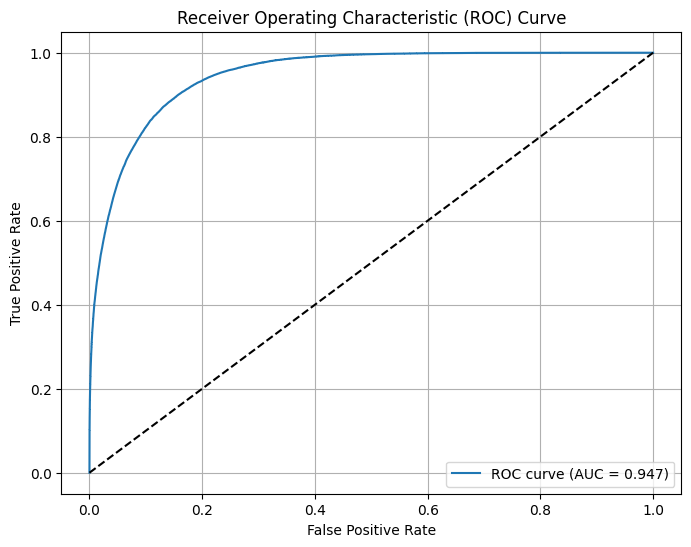

In [7]:
epochs = 500
patience = 5  # epochs to wait for improvement
min_delta = 1e-4  # minimum change to qualify as improvement
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    for xb, yb, yb_reg in train_loader:
        
        xb = xb.to(device)
        yb = yb.to(device).flatten()
        yb_reg = yb_reg.to(device).flatten()

        optimizer.zero_grad()    
        logits = model(xb)
        loss = criterion(logits[:, 0], yb)
        reg_loss = criterion_regression(logits[:, 1], yb_reg)
        total_loss = (1 * loss) + (1 * reg_loss)
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    if epoch % 5 == 0 or epoch == 1:
        with torch.no_grad():
            logits = model(torch.from_numpy(X_train).to(device))
            preds = (torch.sigmoid(logits[:, 0]).cpu().numpy().ravel() >= 0.5).astype(int)
            acc = (preds == y_train).mean() if len(y_train) else float('nan')
            mae = torch.mean(torch.abs(logits[:, 1].cpu() - torch.from_numpy(y_reg_train))).item()
            corr = np.corrcoef(logits[:, 1].cpu().numpy().ravel(), y_reg_train)[0, 1]

        print(f'\nEpoch {epoch:03d} | Loss = {epoch_loss:.4f} | Train_acc = {acc:.3f} | Train_MAE = {mae:.4f} | Train_Corr = {corr:.3f}')

    # ----- Validation (for early stopping) -----
#     model.eval()
#     val_running_loss = 0.0
#     acc = []
#     with torch.no_grad():
#         for xb, yb, yb_reg in test_loader:
#             xb = xb.to(device)
#             yb = yb.to(device).flatten()
#             yb_reg = yb_reg.to(device).flatten()
#             logits = model(xb)
#             v_loss_cls = criterion(logits[:, 0], yb)
#             v_loss_reg = criterion_regression(logits[:, 1], yb_reg)
#             val_running_loss += (v_loss_cls + v_loss_reg).item() * xb.size(0)
#             preds_test = (torch.sigmoid(logits[:, 0]).cpu().numpy().ravel() >= 0.5).astype(int)
#             acc.append((preds_test == yb.detach().cpu().numpy()).mean() if len(yb) else float('nan'))
#     val_loss = val_running_loss / len(test_loader.dataset)
#     print (f'Epoch {epoch:03d} | Loss = {total_loss.item():.4f} | Classification Loss: {loss.item():.4f} | Regression Loss: {reg_loss.item():.4f} | Test Accuracy: {np.mean(np.array(acc))}', end='\r')

#     # Check improvement
#     if val_loss < (best_val_loss - min_delta):
#         best_val_loss = val_loss
#         best_state = copy.deepcopy(model.state_dict())
#         epochs_no_improve = 0
#     else:
#         epochs_no_improve += 1
#         if epochs_no_improve >= patience:
#             print(f'Early stopping at epoch {epoch} (no improvement for {patience} epochs). Best val loss: {best_val_loss:.4f}')
#             break

# # Restore best model (if captured)
# if best_state is not None:
#     model.load_state_dict(best_state)

# 7) Evaluate on test set
model.eval()
with torch.no_grad():
    logits = model(torch.from_numpy(X_test).to(device))
    probs = torch.sigmoid(logits[:, 0]).cpu().numpy().ravel()
    y_pred = (probs >= 0.5).astype(int)
    y_reg_pred = logits[:, 1].cpu().numpy().ravel()
test_acc = (y_pred == y_test).mean() if len(y_test) else float('nan')
reg_test_mae = torch.mean(torch.abs(torch.tensor(y_reg_pred) - torch.tensor(y_reg_test))).item() if len(y_reg_test) else float('nan')
print(f'Test regression MAE: {reg_test_mae:.4f}')
print(f'Test accuracy: {test_acc:.3f}  (n_test={len(y_test)})')

# Precision, Recall, F1
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
print(f'Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}')

roc_auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()



# # Show learned weights with feature names
# coef = model.linear.weight[0].detach().cpu().numpy().ravel()
# bias = float(model.linear.bias[0].detach().cpu().numpy().ravel())

# coef_reg = model.linear.weight[1].detach().cpu().numpy().ravel()
# bias_reg = float(model.linear.bias[1].detach().cpu().numpy().ravel())

# coef_table = pd.DataFrame({'Features': feature_cols, 'Classification Weights': coef, 'Regression Weights': coef_reg}).sort_values('Classification Weights', ascending=False).reset_index(drop=True)
# print('Bias:', bias)
# print('Regression Bias:', bias_reg)
# display(coef_table)

torch.save(model.state_dict(), os.path.join(cache_path, 'alpaca_multi_model_calendar_spread_v2.pth'))


In [10]:
# torch.save(model.state_dict(), os.path.join(cache_path, 'alpaca_multi_model_calendar_spread_v2.pth'))

# min_reg_scale = np.min(y_reg_train)
# denom_reg_scale = np.ptp(y_reg_train) + 1e-8

# with open(os.path.join(cache_path, 'alpaca_multi_model_calendar_spread_v2_params.pkl'), 'wb') as file: 
#     pkl.dump({
#         'mean_': mean_,
#         'std_': std_,
#         'min_reg_scale': min_reg_scale,
#         'denom_reg_scale': denom_reg_scale
#     }, file)

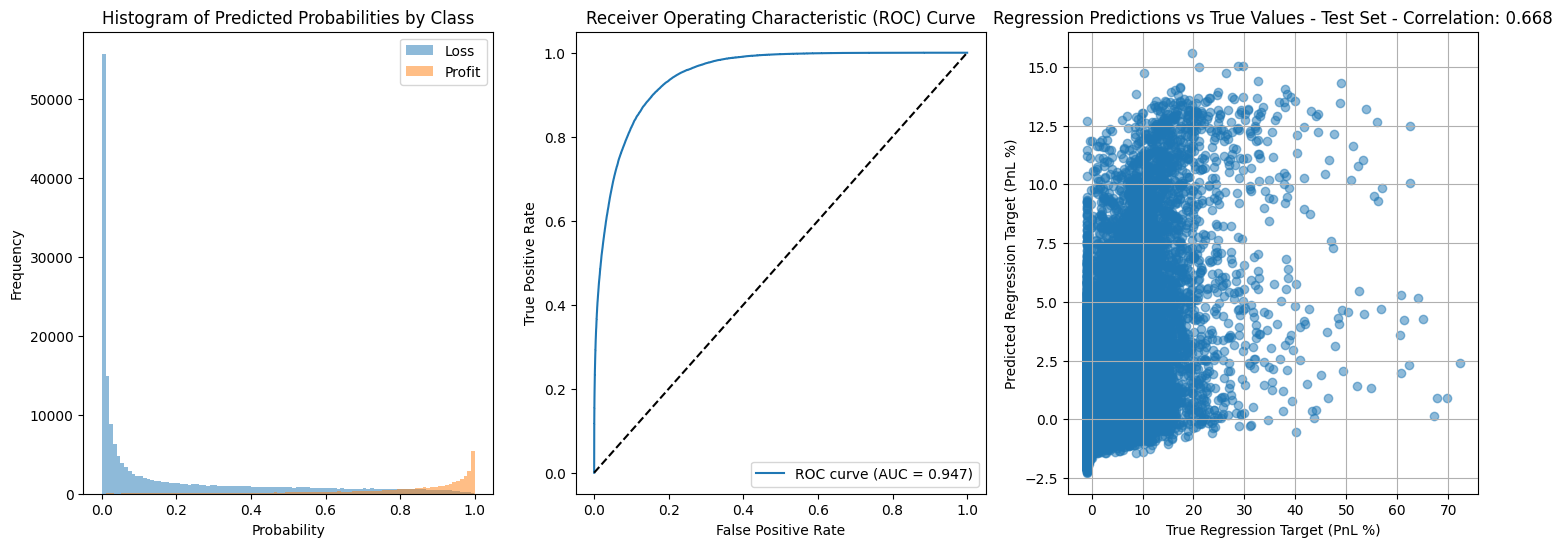

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
axs[0].hist(probs[np.where(y_test == 0)[0]], bins=100, alpha=0.5, label='Loss')
axs[0].hist(probs[np.where(y_test == 1)[0]], bins=100, alpha=0.5, label='Profit')
axs[0].set_xlabel('Probability')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Histogram of Predicted Probabilities by Class')
axs[0].legend()

axs[1].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
axs[1].plot([0, 1], [0, 1], 'k--')
axs[1].set_xlabel('False Positive Rate')
axs[1].set_ylabel('True Positive Rate')
axs[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axs[1].legend()

axs[2].scatter(invert_reg_scale(y_reg_test, denom_reg_scale, min_reg_scale), invert_reg_scale(y_reg_pred, denom_reg_scale, min_reg_scale), alpha=0.5)
axs[2].set_xlabel('True Regression Target (PnL %)')
axs[2].set_ylabel('Predicted Regression Target (PnL %)')
axs[2].set_title(f'Regression Predictions vs True Values - Test Set - Correlation: {np.corrcoef(y_reg_test, y_reg_pred)[0, 1]:.3f}')
axs[2].grid()
plt.show()

Per-symbol ROC AUC (NaN = not computable due to single class):


,Symbol,n,pos_rate,roc_auc
0,TSLA,114355,0.202483,0.978483
1,SPY,214445,0.151722,0.977501
2,NVDA,97557,0.158277,0.972734
3,GLD,58552,0.183102,0.969024
4,CRWV,4377,0.302262,0.958277
5,NFLX,47617,0.208623,0.954835
6,QQQ,143857,0.173165,0.947692
7,META,102360,0.229611,0.946752
8,MSFT,88499,0.143493,0.921713
9,AAPL,53540,0.165278,0.909037



Per-symbol + Option Type ROC AUC (NaN = not computable due to single class):


,Symbol,OptionType,n,pos_rate,roc_auc
0,AAPL,call,23441,0.223668,0.916030
1,AAPL,put,30099,0.119805,0.887374
2,AMZN,call,19457,0.281749,0.854330
3,AMZN,put,32171,0.101582,0.904509
4,CAT,call,7465,0.432686,0.668855
5,CAT,put,11054,0.172879,0.764417
6,CEG,call,2349,0.410387,0.639760
7,CEG,put,2505,0.071856,0.557544
8,CRWV,call,2605,0.482150,0.929007
9,CRWV,put,1772,0.037810,0.924962


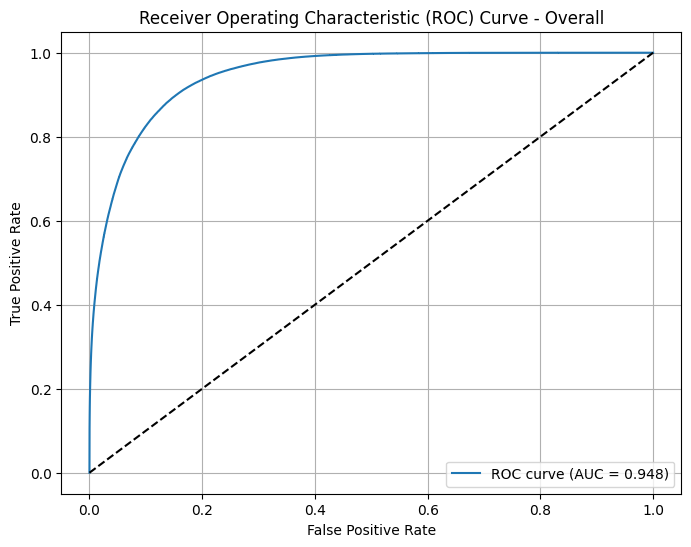

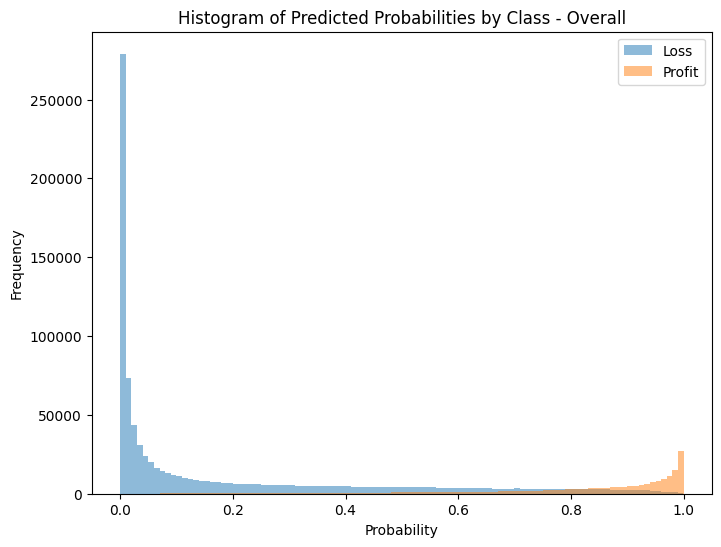

In [18]:
# Test set 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model_path='/Users/zohairshafi/Local Workspace/spectral_nature/cache'
model_name='alpaca_multi_model_calendar_spread_v2.pth'
params_name='alpaca_multi_model_calendar_spread_params_v2.pkl'

model = MultiModel(in_dim = len(feature_cols)).to(device)
model.load_state_dict(torch.load(os.path.join(model_path, model_name), map_location=device))
with open(os.path.join(model_path, params_name), 'rb') as file: 
    model_params = pkl.load(file)

mean_ = model_params['mean_']
std_ = model_params['std_']
min_reg_scale = model_params['min_reg_scale']
denom_reg_scale = model_params['denom_reg_scale']

model.eval()

# Build modeling frame for inference including Symbol, Option Type, and PnL for per-symbol metrics
df_model = data[feature_cols + ['PnL', 'Symbol']].copy()

# Clean and standardize
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols + ['PnL', 'Symbol'])
X_options = df_model[feature_cols].to_numpy(dtype=np.float32)
X_options = (X_options - mean_) / std_

# Inference
logits = model(torch.from_numpy(X_options).to(device))
probs = torch.sigmoid(logits[:, 0]).detach().cpu().numpy().ravel()
y_reg_pred = logits[:, 1].detach().cpu().numpy().ravel()
y_reg_pred_original = invert_reg_scale(y_reg_pred, denom_reg_scale, min_reg_scale)

# Overall metrics
df_model['prob'] = probs
df_model['label'] = (df_model['PnL'] > 0).astype(int)
y_overall = df_model['label'].to_numpy()

# Handle degenerate case where only one class exists overall
roc_auc = np.nan
if len(np.unique(y_overall)) > 1:
    roc_auc = roc_auc_score(y_overall, probs)
    fpr, tpr, _ = roc_curve(y_overall, probs)
else:
    fpr, tpr = np.array([0, 1]), np.array([0, 1])

# Per-symbol AUC characteristics
rows = []
for sym, grp in df_model.groupby('Symbol'):
    y_sym = grp['label'].to_numpy()
    p_sym = grp['prob'].to_numpy()
    if len(np.unique(y_sym)) < 2:
        sym_auc = np.nan  # cannot compute ROC AUC with single class
    else:
        sym_auc = roc_auc_score(y_sym, p_sym)
    rows.append({
        'Symbol': sym,
        'n': int(len(grp)),
        'pos_rate': float(y_sym.mean()) if len(y_sym) else np.nan,
        'roc_auc': float(sym_auc) if sym_auc == sym_auc else np.nan  # keep NaN if not computable
    })
auc_by_symbol = pd.DataFrame(rows).sort_values(['roc_auc', 'n'], ascending=[False, False])

# Per-symbol & option type AUC characteristics (Option Type may be part of feature_cols)
# If Option Type exists in df_model columns proceed; else skip gracefully
if 'Option Type' in df_model.columns:
    rows_opt = []
    # Map numeric to string for readability
    type_map = {1: 'call', 0: 'put'}
    for (sym, opt_type), grp in df_model.groupby(['Symbol', 'Option Type']):
        y_grp = grp['label'].to_numpy()
        p_grp = grp['prob'].to_numpy()
        if len(np.unique(y_grp)) < 2:
            grp_auc = np.nan
        else:
            grp_auc = roc_auc_score(y_grp, p_grp)
        rows_opt.append({
            'Symbol': sym,
            'OptionTypeRaw': int(opt_type),
            'OptionType': type_map.get(int(opt_type), str(opt_type)),
            'n': int(len(grp)),
            'pos_rate': float(y_grp.mean()) if len(y_grp) else np.nan,
            'roc_auc': float(grp_auc) if grp_auc == grp_auc else np.nan
        })
    auc_by_symbol_option = pd.DataFrame(rows_opt).sort_values(['roc_auc', 'n'], ascending=[False, False])
else:
    auc_by_symbol_option = pd.DataFrame(columns=['Symbol','OptionType','n','pos_rate','roc_auc'])

# Display per-symbol table
print('Per-symbol ROC AUC (NaN = not computable due to single class):')
display(auc_by_symbol.reset_index(drop=True))

print('\nPer-symbol + Option Type ROC AUC (NaN = not computable due to single class):')
auc_by_symbol_option = auc_by_symbol_option.drop(columns=['OptionTypeRaw'])
auc_by_symbol_option.sort_values(['Symbol', 'OptionType'], inplace=True)
display(auc_by_symbol_option.reset_index(drop=True))

# Existing overall visualizations
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})' if roc_auc == roc_auc else 'ROC curve (AUC = N/A)')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Overall')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(df_model.loc[y_overall == 0, 'prob'], bins=100, alpha=0.5, label='Loss')
plt.hist(df_model.loc[y_overall == 1, 'prob'], bins=100, alpha=0.5, label='Profit')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Predicted Probabilities by Class - Overall')
plt.legend()
plt.show()

In [23]:
symbol = 'GLD'

########################################
####### Get options information ########
########################################
option_details, strike_group, current_price = get_options_information(symbol = symbol,
                                                                       start_day_offset = 30,
                                                                       end_day_offset = 120,
                                                                       option_type = 'call',
                                                                       percentage_to_search = 0.1,
                                                                       headers = headers)
display(option_details)

########################################
####### Filter Possible Trades #########
########################################
o = filter_option_trades_by_ff(strike_group = strike_group,
                           current_price = current_price,
                           min_time_distance = 10,
                           max_time_distance = 120,
                           min_ff_perc = 1, 
                           max_ff_perc = 50, 
                           print_output = False)

list_of_options = []
for idx, options_df in enumerate(o):
    conf, reg_pred = get_model_confidence(underlying_price = current_price,
                                          options_df = options_df, 
                                          model_name='alpaca_multi_model_calendar_spread_v2.pth',
                                          params_name='alpaca_multi_model_calendar_spread_params_v2.pkl')
    list_of_options.append((conf, reg_pred, options_df))

sorted_options = sorted(list_of_options, key=lambda x: x[0][0], reverse=True)

for conf, reg_pred, options_df in sorted_options:
    print(f"Profit Probability: {conf[0] * 100:0.3f}%\nModel Regression Predictions: {reg_pred[0] * 100:0.3f}%")
    display(options_df)

Symbol | GLD
Current Price: 376.58 (Time : 2025-11-14T19:23:00Z)


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price
0,GLD251219C00377000,2025-12-19,377,14.9,call,0.5294,0.0151,0.1806,-0.1698,0.464,0.2254,11.02,10.95
1,GLD251226C00377000,2025-12-26,377,16.14,call,0.5333,0.0141,0.2174,-0.1538,0.5079,0.2206,11.98,11.78
2,GLD251231C00377000,2025-12-31,377,16.65,call,0.5358,0.0134,0.2437,-0.1457,0.5369,0.2193,12.59,12.53
3,GLD260116C00377000,2026-01-16,377,18.65,call,0.5431,0.0119,0.3282,-0.1253,0.6205,0.2131,14.57,14.13
4,GLD260220C00377000,2026-02-20,377,24.61,call,0.5552,0.0093,0.5115,-0.1054,0.771,0.2167,18.71,18.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,GLD260220C00413000,2026-02-20,413,8.92,call,0.2652,0.0073,0.2498,-0.0849,0.6394,0.2301,6.93,6.72
193,GLD251219C00414000,2025-12-19,414,4.08,call,0.1314,0.0072,0.0457,-0.0951,0.2486,0.2533,1.94,1.83
194,GLD251231C00414000,2025-12-31,414,4.04,call,0.1615,0.0075,0.0748,-0.0915,0.3308,0.2421,2.77,2.59
195,GLD260116C00414000,2026-01-16,414,5.6,call,0.1998,0.0075,0.123,-0.0901,0.4377,0.2374,3.98,3.93


Profit Probability: 95.588%
Model Regression Predictions: 5.213%


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,GLD251219C00391000,2025-12-19,391,8.6,call,0.3370,0.0131,0.1160,-0.1580,0.4258,0.2382,6.04,5.89,12.538269,-3.44
1,GLD260116C00391000,2026-01-16,391,12.13,call,0.3897,0.0108,0.2374,-0.1227,0.6002,0.2266,9.33,9.13,12.538269,-3.44


Profit Probability: 95.521%
Model Regression Predictions: 5.194%


...

,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,GLD251231C00413000,2025-12-31,413,4,call,0.1683,0.0077,0.0780,-0.0940,0.3397,0.2420,2.92,2.72,6.836771,-1.49
1,GLD260116C00413000,2026-01-16,413,7.35,call,0.2074,0.0077,0.1277,-0.0925,0.4477,0.2381,4.21,4.11,6.836771,-1.49


Profit Probability: 66.591%
Model Regression Predictions: 3.126%


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,GLD251219C00413000,2025-12-19,413,2.9,call,0.1394,0.0075,0.0484,-0.0996,0.2588,0.2546,2.07,2.00,18.020725,-4.93
1,GLD260220C00413000,2026-02-20,413,8.92,call,0.2652,0.0073,0.2498,-0.0849,0.6394,0.2301,6.93,6.72,18.020725,-4.93


Profit Probability: 64.986%
Model Regression Predictions: 2.454%


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,GLD251231C00414000,2025-12-31,414,4.04,call,0.1615,0.0075,0.0748,-0.0915,0.3308,0.2421,2.77,2.59,8.401096,-1.39
1,GLD260116C00414000,2026-01-16,414,5.6,call,0.1998,0.0075,0.1230,-0.0901,0.4377,0.2374,3.98,3.93,8.401096,-1.39
